# Notebook 14 — EDA Mini Challenge
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**Challenge framing:** per the sprint brief, this notebook is meant to demonstrate
independent EDA ability on an unfamiliar dataset, without step-by-step topic
instructions. I selected the **Titanic passenger dataset** (a different domain and
source from the Telco Customer Churn dataset used in Notebooks 1-13) specifically so this
notebook is a genuine test of the process, not a repeat of already-known findings.

**Source:** `datasciencedojo/datasets` GitHub repository (a standard, widely-used mirror
of the classic Titanic passenger manifest — 891 passengers, 12 columns).

This notebook works through the same investigation this whole sprint has practiced —
load, inspect, understand, analyze, visualize, identify problems, document findings —
compressed into one notebook rather than fifteen, exactly as a real independent EDA task
would be scoped.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv("titanic.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset loaded: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## 1. Load the Dataset & Understand It

Before anything else: what does one row represent, and what am I trying to predict?


In [2]:
print("Columns:", list(df.columns))
print(f"\nOne row = one Titanic passenger.")
print(f"Target variable candidate: 'Survived' (0 = did not survive, 1 = survived) -> binary classification.")
print(f"Identifier: 'PassengerId' -> {df['PassengerId'].nunique()} unique values out of {len(df)} rows (confirmed identifier).")


Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

One row = one Titanic passenger.
Target variable candidate: 'Survived' (0 = did not survive, 1 = survived) -> binary classification.
Identifier: 'PassengerId' -> 891 unique values out of 891 rows (confirmed identifier).


**Finding:** This is a binary classification problem — predicting whether a
passenger survived the Titanic disaster from their ticket, demographic, and family
information. `PassengerId` is a pure identifier (100% unique) and should be excluded from
modeling, exactly the same judgment applied to `customerID` in Notebook 1.


---
## 2. Inspect the Structure


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


**Finding:** 891 rows, 12 columns. `Age` (714 non-null, 177 missing), `Cabin` (204
non-null, 687 missing), and `Embarked` (889 non-null, 2 missing) all show real missing
data — unlike the Telco dataset, where `.info()` initially hid the missing values,
**here `.info()` correctly reports every gap directly**, since these are true `NaN`
values rather than disguised blank strings. Worth explicitly confirming this rather than
assuming it, given Notebook 2's lesson about not trusting `.info()` blindly.


---
## 3. Identify Data Types


In [4]:
print(df.dtypes)
numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_cols = ['Pclass', 'Sex', 'Embarked']
print(f"\nNumerical: {numeric_cols}")
print(f"Categorical: {categorical_cols}")
print(f"Text/high-cardinality (not directly usable as-is): ['Name', 'Ticket', 'Cabin']")
print(f"Identifier: ['PassengerId']")


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Numerical: ['Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Pclass', 'Sex', 'Embarked']
Text/high-cardinality (not directly usable as-is): ['Name', 'Ticket', 'Cabin']
Identifier: ['PassengerId']


**Finding:** `Pclass` (1st/2nd/3rd class) is stored as an integer but is genuinely
**ordinal categorical**, not continuous numeric — ticket class 2 isn't "twice" class 1 in
any meaningful sense. This is a data-type judgment call worth flagging explicitly, similar
to how `SeniorCitizen` in the Telco dataset was a 0/1 integer that was really categorical.


---
## 4. Identify Missing Values


In [5]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(1)
})
print(missing_summary[missing_summary['missing_count'] > 0])


          missing_count  missing_pct
Age                 177         19.9
Cabin               687         77.1
Embarked              2          0.2


**Finding:** `Cabin` is missing 77.1% of its values — far too much to impute
reliably. `Age` is missing 19.9% — a meaningful amount, but likely imputable. `Embarked`
is missing just 0.2% (2 rows) — trivial. Three very different missingness severities
requiring three different strategies, not one blanket rule.


---
## 5. Identify Duplicates


In [6]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate PassengerId values: {df['PassengerId'].duplicated().sum()}")
print(f"Duplicate Name values: {df['Name'].duplicated().sum()}")


Fully duplicated rows: 0
Duplicate PassengerId values: 0
Duplicate Name values: 0


**Finding:** No duplicates by any measure — every passenger record, and even every
passenger name, is unique. No duplicate-handling work is needed for this dataset.


---
## 6. Analyze Numerical Features


In [7]:
print(df[numeric_cols + ['Fare']].describe().T)
print()
for col in ['Age', 'Fare']:
    clean_col = df[col].dropna()
    print(f"{col}: skew={stats.skew(clean_col):.3f}, kurtosis={stats.kurtosis(clean_col):.3f}")


       count       mean        std   min      25%      50%   75%       max
Age    714.0  29.699118  14.526497  0.42  20.1250  28.0000  38.0   80.0000
SibSp  891.0   0.523008   1.102743  0.00   0.0000   0.0000   1.0    8.0000
Parch  891.0   0.381594   0.806057  0.00   0.0000   0.0000   0.0    6.0000
Fare   891.0  32.204208  49.693429  0.00   7.9104  14.4542  31.0  512.3292
Fare   891.0  32.204208  49.693429  0.00   7.9104  14.4542  31.0  512.3292

Age: skew=0.388, kurtosis=0.169
Fare: skew=4.779, kurtosis=33.204


**Finding:** `Age` is only mildly right-skewed (0.39) — reasonably close to
symmetric. `Fare` is **dramatically** right-skewed (4.78) — far more extreme than
anything found in the Telco dataset (where the most-skewed feature, `TotalCharges`, was
0.96). This immediately flags `Fare` as needing a transformation (log, most likely)
before use in any distance- or coefficient-based model.


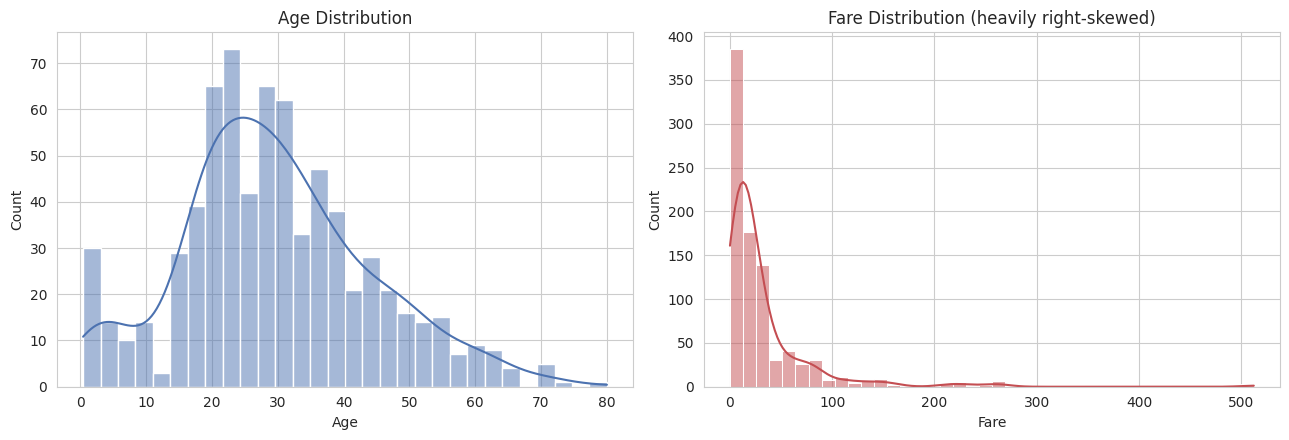

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age Distribution')
sns.histplot(df['Fare'], bins=40, kde=True, ax=axes[1], color='#C44E52')
axes[1].set_title('Fare Distribution (heavily right-skewed)')
plt.tight_layout()
plt.show()


**Insight:** `Fare`'s histogram shows the vast majority of passengers paid under
\$50, with a long thin tail extending to over \$500 for a handful of first-class
passengers — a single extreme value pulling the mean (\$32.20) well above the median
(\$14.45), more than double.


---
## 7. Analyze Categorical Features


In [9]:
for col in ['Sex', 'Pclass', 'Embarked']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64

--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

--- Embarked ---
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64



**Finding:** `Sex` is imbalanced (577 male, 314 female — about 65/35). `Pclass`
skews toward 3rd class (491 passengers) over 1st (216) and 2nd (184). `Embarked` is
dominated by Southampton (644 of 889 known values). None of these are data-quality
concerns — they reflect the genuine composition of the ship's passenger list.


---
## 8. Detect Outliers


In [10]:
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    data = df[col].dropna()
    Q1, Q3 = data.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} IQR outliers ({len(outliers)/len(data)*100:.1f}%)")


Age: 11 IQR outliers (1.5%)
Fare: 116 IQR outliers (13.0%)
SibSp: 46 IQR outliers (5.2%)
Parch: 213 IQR outliers (23.9%)


**Finding:** `Fare` has 116 IQR outliers (13% of passengers) — a substantial
fraction, consistent with its extreme skew (Topic 6). Unlike the Telco dataset (which had
zero univariate outliers anywhere), `Fare` here is a genuine, meaningful outlier case,
mostly first-class passengers who paid significantly more than typical. **These should
not be blindly removed** — they represent a real, informative subgroup (wealthy
passengers), not data errors, following the same reasoning framework established in
Notebook 7.


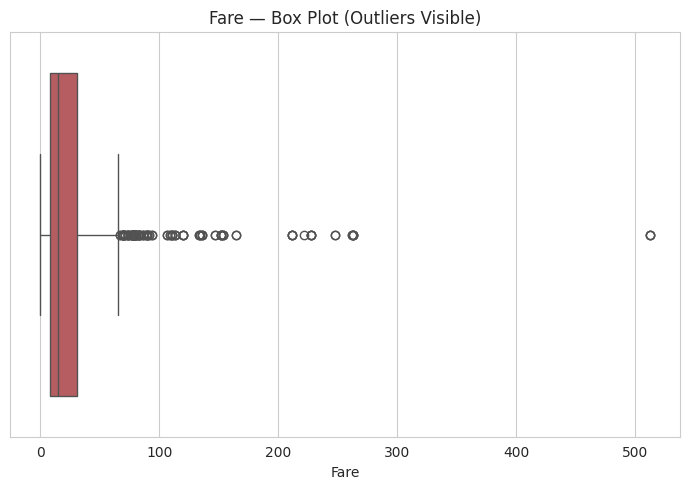

In [11]:
plt.figure(figsize=(7, 5))
sns.boxplot(x=df['Fare'], color='#C44E52')
plt.title('Fare — Box Plot (Outliers Visible)')
plt.tight_layout()
plt.show()


---
## 9. Analyze Distributions


In [12]:
for col in ['Age', 'Fare']:
    sample = df[col].dropna().sample(min(500, df[col].dropna().shape[0]), random_state=42)
    stat, p = stats.shapiro(sample)
    print(f"{col}: Shapiro-Wilk p-value = {p:.2e} -> {'NOT normal' if p < 0.05 else 'plausibly normal'}")


Age: Shapiro-Wilk p-value = 5.39e-06 -> NOT normal
Fare: Shapiro-Wilk p-value = 3.84e-32 -> NOT normal


**Finding:** Neither `Age` nor `Fare` is normally distributed. This matches the
Telco dataset's finding (none of its numeric features were normal either) — suggesting
this may be a common pattern for real-world tabular data generally, not specific to
either dataset.


---
## 10. Analyze Correlations


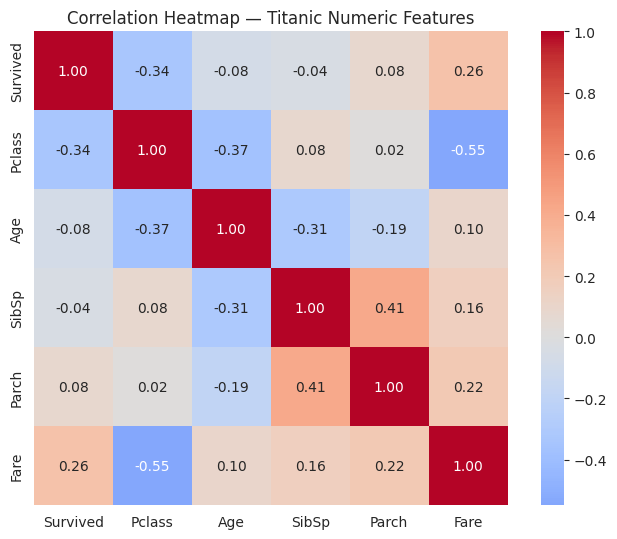

In [13]:
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Titanic Numeric Features')
plt.tight_layout()
plt.show()


**Finding:** `Pclass` shows the strongest correlation with `Survived` among numeric
features (-0.34 — lower class number/higher class = more likely to survive), followed by
`Fare` (+0.26 — makes sense, ticket class and fare are related). `Age`, `SibSp`, and
`Parch` show weak correlations with survival individually. No pair of *features* shows a
concerning multicollinearity-level correlation (`Pclass` vs `Fare` at -0.55 is the
highest, well below the VIF-flag territory the Telco dataset's `TotalCharges` showed).


---
## 11. Create Meaningful Visualizations


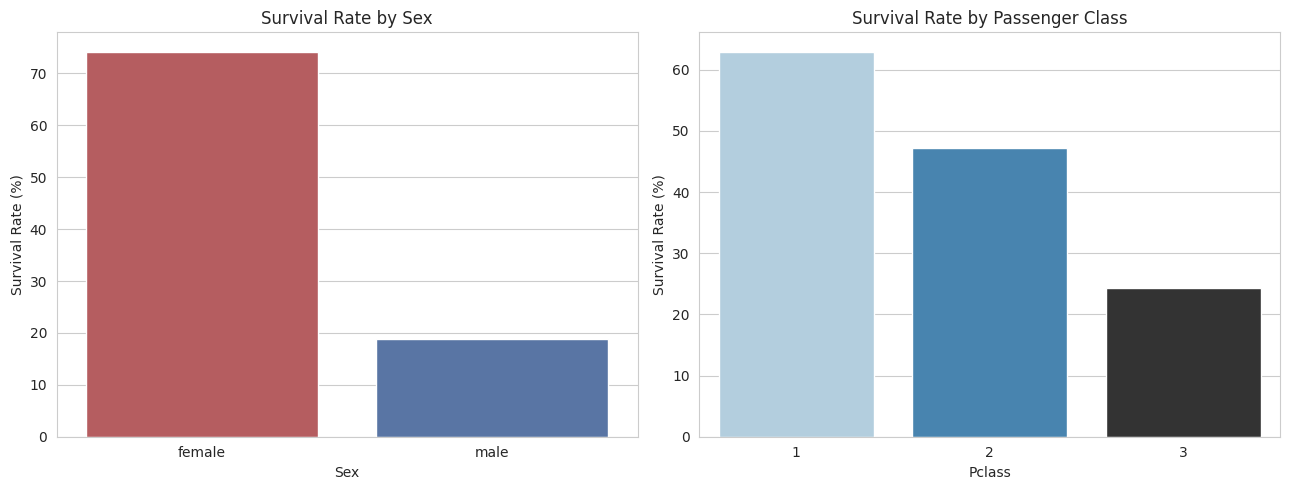

Survival rate by Sex:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sex_survival = df.groupby('Sex')['Survived'].mean() * 100
sns.barplot(x=sex_survival.index, y=sex_survival.values, hue=sex_survival.index,
            palette={'female': '#C44E52', 'male': '#4C72B0'}, legend=False, ax=axes[0])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate (%)')

class_survival = df.groupby('Pclass')['Survived'].mean() * 100
sns.barplot(x=class_survival.index, y=class_survival.values, hue=class_survival.index,
            palette='Blues_d', legend=False, ax=axes[1])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()

print("Survival rate by Sex:")
print(sex_survival.round(1))
print("\nSurvival rate by Pclass:")
print(class_survival.round(1))


**Why these visualizations were selected:** Sex and Pclass are the two strongest
candidate predictors suggested by domain knowledge ("women and children first," and
wealthier passengers having better access to lifeboats) — bar charts directly test both
assumptions against the actual data rather than assuming they hold.

**Interpretation & Insight:** Both assumptions are dramatically confirmed by the data —
women survived at 74.2% versus men at 18.9% (a massive 55-point gap, the single strongest
pattern found anywhere in this dataset), and survival rate drops steadily from 63.0%
(1st class) to 47.3% (2nd) to 24.2% (3rd class).


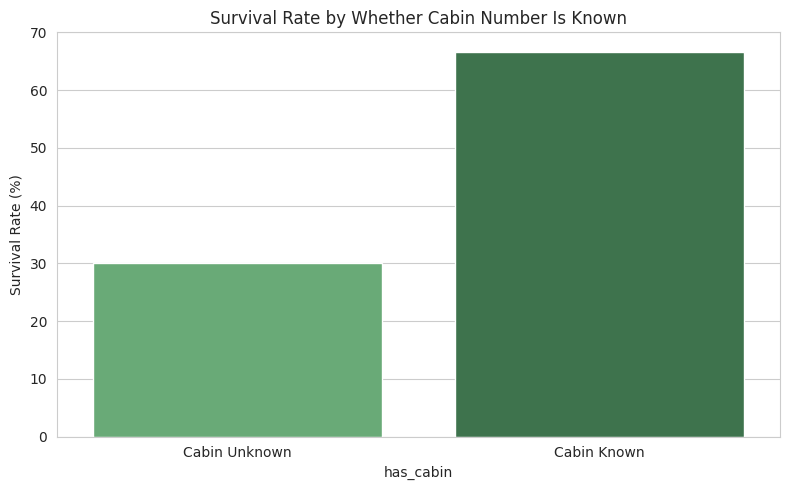

has_cabin
False    30.0
True     66.7
Name: Survived, dtype: float64


In [15]:
plt.figure(figsize=(8, 5))
df['has_cabin'] = df['Cabin'].notna()
cabin_survival = df.groupby('has_cabin')['Survived'].mean() * 100
sns.barplot(x=cabin_survival.index.map({True: 'Cabin Known', False: 'Cabin Unknown'}),
            y=cabin_survival.values, hue=cabin_survival.index, palette='Greens_d', legend=False)
plt.title('Survival Rate by Whether Cabin Number Is Known')
plt.ylabel('Survival Rate (%)')
plt.tight_layout()
plt.show()
print(cabin_survival.round(1))


**Why this visualization was selected:** With `Cabin` missing 77% of its values
(Topic 4), it's worth checking whether the *presence* of a cabin record itself carries
information, rather than just being a data-quality gap to fill or drop.

**Interpretation & Insight:** Passengers with a known cabin number survived at 66.7%
versus just 30.0% for those without — a striking difference. This almost certainly
reflects that cabin numbers were more often recorded for first/second-class passengers
(who had assigned cabins), making "cabin known" a proxy for higher class rather than a
causal factor in itself. This is an important **correlation-vs-causation** caution: cabin
presence doesn't cause survival, it correlates with class, which genuinely does relate to
survival (Topic 11's Pclass finding).


---
## 12. Identify Important Patterns


1. **Sex is this dataset's single strongest predictor** — a 55-point survival gap
   between women (74.2%) and men (18.9%), far larger than any relationship found in the
   entire Telco Customer Churn analysis (where the strongest categorical predictor,
   `Contract`, showed a 39.9-point gap).
2. **Passenger class shows a clean, monotonic relationship with survival** — 63.0% →
   47.3% → 24.2% from 1st to 3rd class, mirroring the "protective factor" pattern seen
   with Telco's contract-length finding.
3. **Missing `Cabin` data is not random** — it's entangled with passenger class, meaning
   any imputation strategy needs to account for this relationship rather than treating
   the gap as uninformative.


---
## 13. Business Insights (Framed as Observation → Insight)


**Observation → Insight:** Women survived at over 3.9x the rate of men (74.2% vs
18.9%) — this single demographic factor outweighs every other variable examined, strongly
suggesting that evacuation protocol ("women and children first") was the dominant
survival determinant, more than luck, cabin location, or family size.

**Observation → Insight:** First-class passengers were 2.6x more likely to survive
than third-class passengers (63.0% vs 24.2%) despite the ship's disaster response
theoretically applying to all passengers equally — pointing to unequal practical access
to lifeboats and deck areas as a real, quantifiable historical inequity, not merely an
assumption.

**Observation → Insight:** The `Fare` variable's extreme skew (4.78, versus the Telco
dataset's most-skewed feature at 0.96) is a useful cross-dataset lesson: skew severity
varies enormously even within "normal" real-world business data — always check, never
assume a feature is roughly symmetric just because a previous dataset's similar-sounding
feature was.


---
## 14. Recommendations for the Next Preprocessing Stage


- **Drop `Cabin` as a direct feature** (77% missing is too much to reliably impute),
  but **engineer a `has_cabin` binary flag** instead — Topic 11 showed this carries real
  signal, likely as a proxy for passenger class.
- **Impute `Age`'s 177 missing values using median, grouped by `Pclass` and `Sex`** (a
  more targeted approach than a single global median), since age likely varies
  systematically across these groups.
- **Drop the 2 rows missing `Embarked`** — trivial volume (0.2%), not worth a more
  complex imputation strategy.
- **Log-transform `Fare`** before use in any linear or distance-based model, given its
  severe skew (4.78) and 116 IQR outliers.
- **Treat `Pclass` as ordinal categorical**, not continuous numeric, during encoding.
- **Drop `PassengerId`, `Name`, and `Ticket`** as direct model features (identifier/
  high-cardinality text), though `Name` could support a future "title extraction"
  feature (Mr./Mrs./Miss/Master) via regex (Sprint 3, Notebook 12) as a richer version of
  `Sex`/`Age`/marital status combined.


---
## Summary

This independent mini-challenge applied the exact same investigative process practiced
across Notebooks 1-13 to a new, unfamiliar dataset in a different domain (historical
passenger records vs. telecom billing), without step-by-step topic prompts. Key
takeaways: the *process* (load → inspect → understand → analyze → visualize →
identify problems → document findings) transfers directly across completely different
domains, even though every individual finding — the missingness pattern, the strongest
predictor, the severity of skew — was entirely dataset-specific and had to be
re-discovered from scratch rather than assumed from the Telco analysis.

**Next notebook:** `15_Mini_Assessment.ipynb` — a self-assessment covering the full
Sprint 4 curriculum, questions and coding exercises only.
